## Load the Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset ##

In [ ]:
df=pd.read_csv("/content/Live.csv")
df

## Dropped the Null value Column ##

In [ ]:
df=df.dropna(axis=1)
df

## Basic Information ##

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         7050 non-null   object
 1   status_type       7050 non-null   object
 2   status_published  7050 non-null   object
 3   num_reactions     7050 non-null   int64 
 4   num_comments      7050 non-null   int64 
 5   num_shares        7050 non-null   int64 
 6   num_likes         7050 non-null   int64 
 7   num_loves         7050 non-null   int64 
 8   num_wows          7050 non-null   int64 
 9   num_hahas         7050 non-null   int64 
 10  num_sads          7050 non-null   int64 
 11  num_angrys        7050 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 661.1+ KB


In [ ]:
df.head()

In [ ]:
df.describe()

## Check Missing Value

In [ ]:
df.isnull().sum()

## Check for Duplicate Value

In [ ]:
df[df.duplicated(keep=False)].sort_values(by='status_id')

## Drop Duplicate Value

In [ ]:
df = df.drop_duplicates()

## Verify Shape of Dataset

In [ ]:
print(df.shape)

(6999, 12)


## EDA (Visualization)

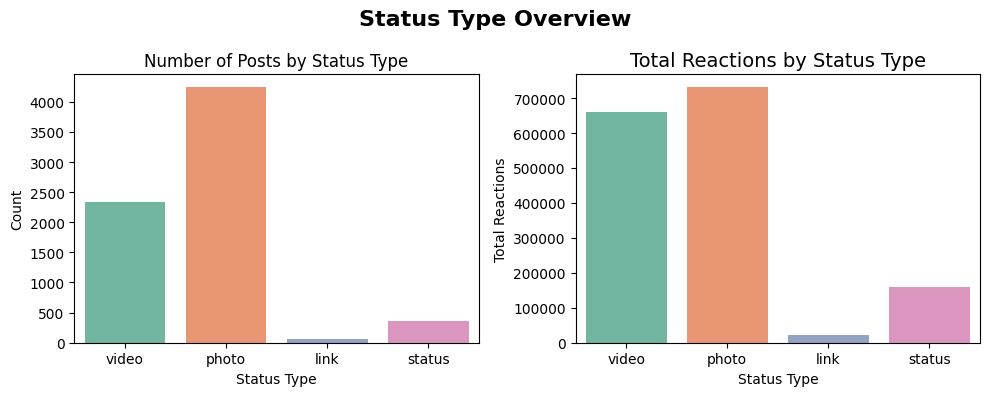

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x='status_type', hue='status_type', ax=axes[0],palette='Set2', legend=False)
axes[0].set_title('Number of Posts by Status Type')
axes[0].set_xlabel('Status Type')
axes[0].set_ylabel('Count')

sns.barplot(data=df,x='status_type',y='num_reactions', estimator='sum',errorbar=None,ax=axes[1],
  hue='status_type', palette='Set2',legend=False )

axes[1].set_title('Total Reactions by Status Type', fontsize=14)
axes[1].set_xlabel('Status Type')
axes[1].set_ylabel('Total Reactions')

plt.suptitle('Status Type Overview', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

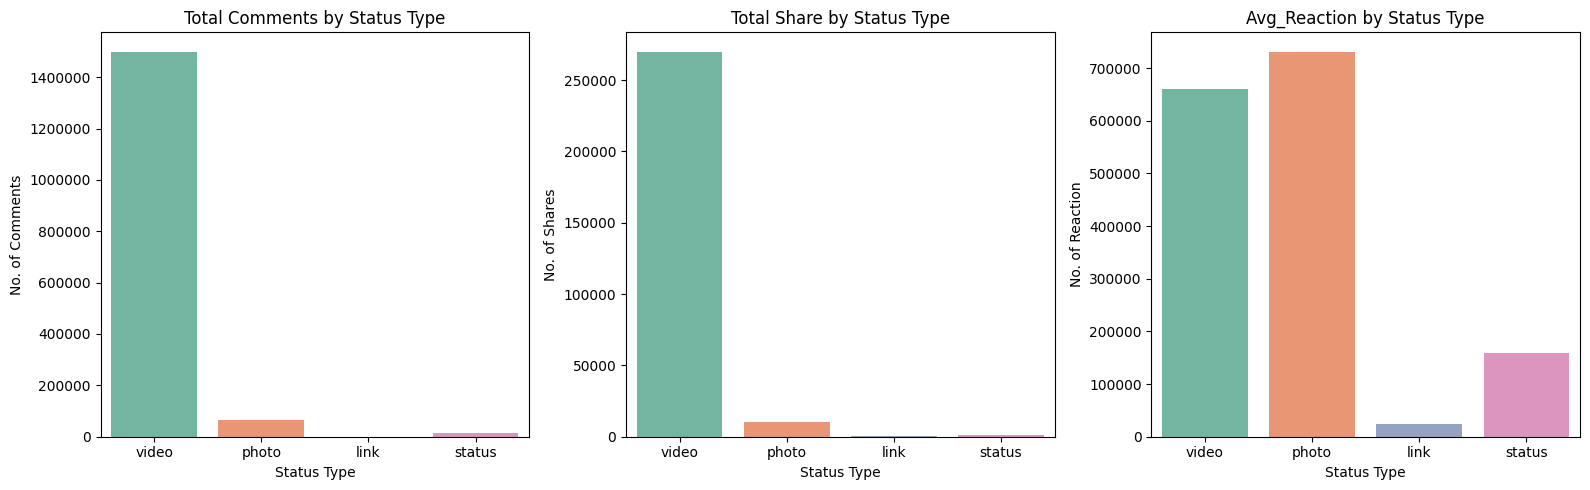

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(16,5))
sns.barplot(data=df, x='status_type', y='num_comments', ax=axes[0],  hue='status_type',
            estimator='sum', palette='Set2',legend=False, errorbar=None)
axes[0].set_title('Total Comments by Status Type')
axes[0].set_xlabel('Status Type')
axes[0].set_ylabel('No. of Comments')
axes[0].ticklabel_format(style='plain', axis='y')
sns.barplot(data=df, x='status_type', y='num_shares', ax=axes[1],  hue='status_type',
            estimator='sum', palette='Set2',legend=False, errorbar=None)
axes[1].set_title('Total Share by Status Type')
axes[1].set_xlabel('Status Type')
axes[1].set_ylabel('No. of Shares')

sns.barplot(data=df, x='status_type', y='num_reactions', ax=axes[2],  hue='status_type',
            estimator='sum', palette='Set2',legend=False, errorbar=None)
axes[2].set_title('Avg_Reaction by Status Type')
axes[2].set_xlabel('Status Type')
axes[2].set_ylabel('No. of Reaction')
plt.tight_layout()
plt.show()

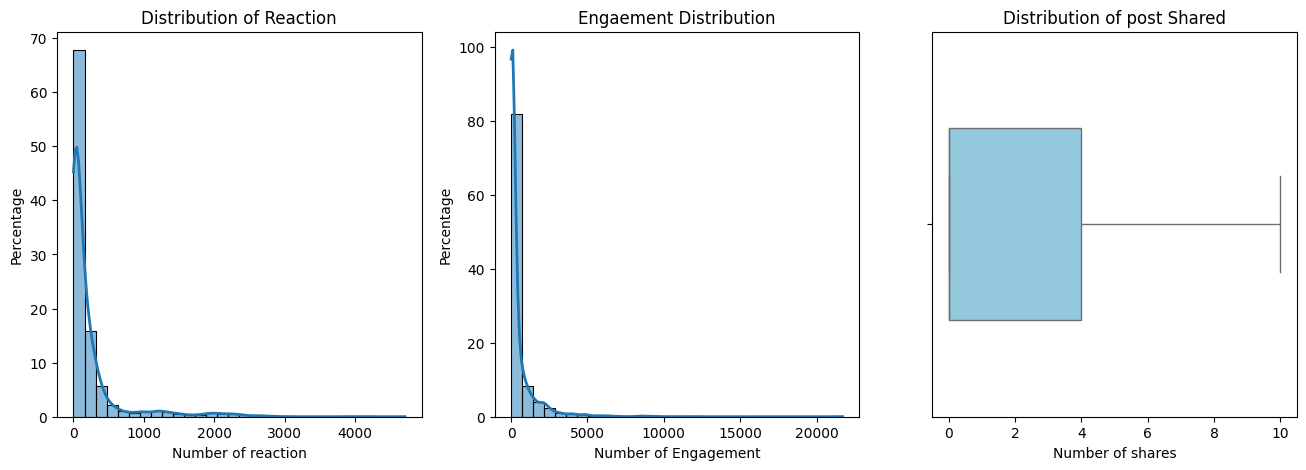

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(16,5))
sns.histplot(df['num_reactions'], bins=30, kde=True,ax=axes[0], line_kws={'linewidth':2},stat='percent')
axes[0].set_title('Distribution of Reaction')
axes[0].set_xlabel('Number of reaction')
axes[0].set_ylabel('Percentage')

df['engagement']= (df['num_reactions']+df['num_comments']+df['num_shares'])
sns.histplot(df['engagement'], bins=30, kde=True, ax=axes[1], line_kws={'linewidth':2},stat='percent')
axes[1].set_title('Engaement Distribution')
axes[1].set_xlabel('Number of Engagement')
axes[1].set_ylabel('Percentage')

sns.boxplot(x=df['num_shares'], ax=axes[2], showfliers=False,width=0.5, color='skyblue')
axes[2].set_title('Distribution of post Shared')
axes[2].set_xlabel('Number of shares')
plt.tight_layout

plt.show()

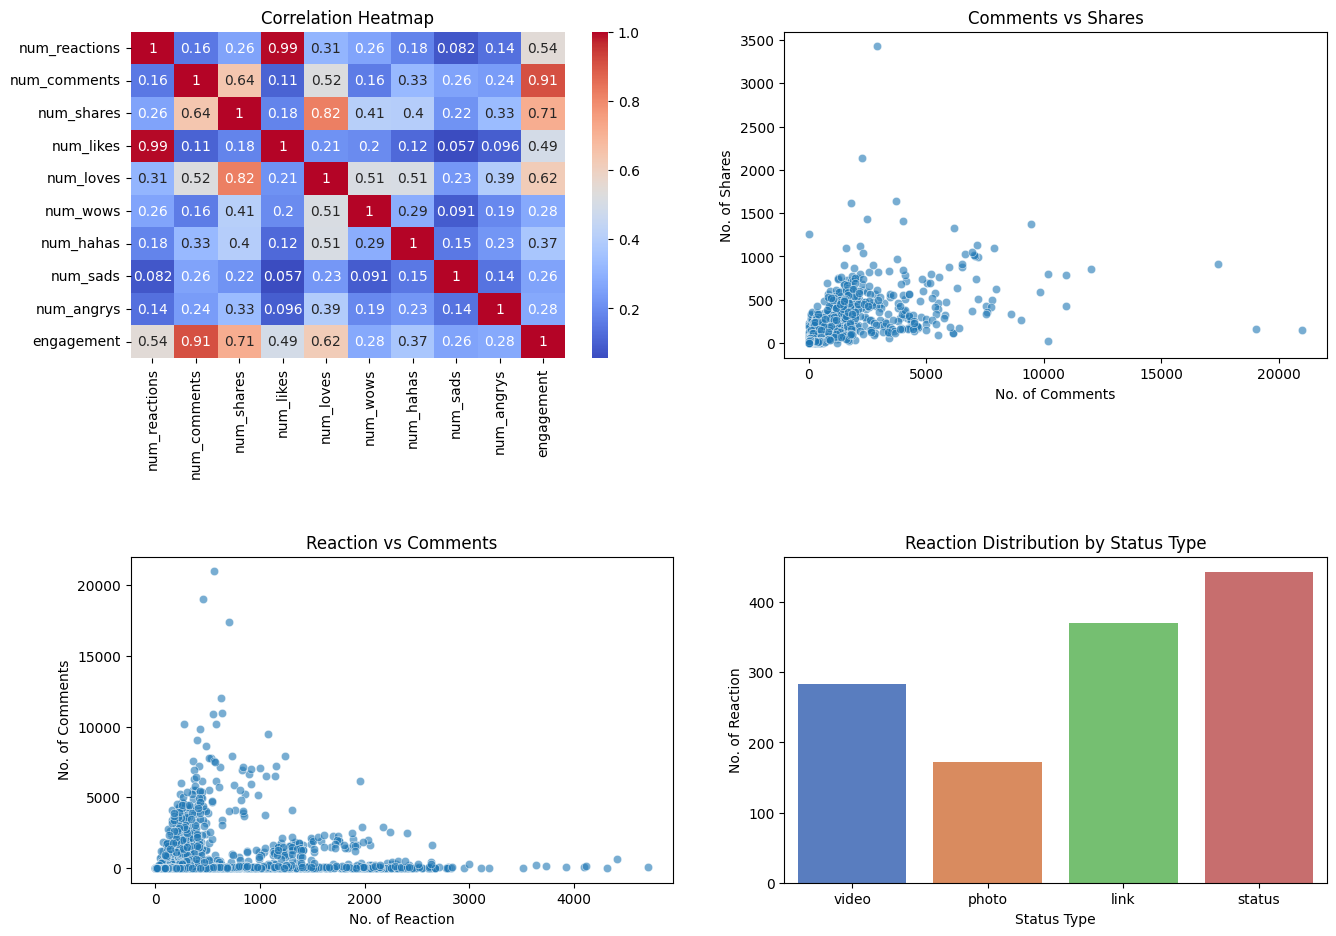

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.heatmap(df.select_dtypes(include='number').corr(),
annot=True, cmap='coolwarm', ax=axes[0,0])
axes[0,0].set_title('Correlation Heatmap')

sns.scatterplot(data=df, x='num_comments', y='num_shares', alpha=0.6, ax=axes[0,1])
axes[0,1].set_title('Comments vs Shares')
axes[0,1].set_xlabel('No. of Comments')
axes[0,1].set_ylabel('No. of Shares')

sns.scatterplot(data=df, x='num_reactions', y='num_comments', alpha=0.6, ax=axes[1,0])
axes[1,0].set_title('Reaction vs Comments')
axes[1,0].set_xlabel('No. of Reaction')
axes[1,0].set_ylabel('No. of Comments')

sns.barplot(data=df, x='status_type', y='num_reactions', ax=axes[1,1], palette='muted', hue='status_type', errorbar=None)
axes[1,1].set_title('Reaction Distribution by Status Type')
axes[1,1].set_xlabel('Status Type')
axes[1,1].set_ylabel('No. of Reaction')

plt.tight_layout(pad=3, h_pad=4, w_pad=4)
plt.show()

# EDA Summary

### Key Findings

- Video posts generated the highest overall engagement (reactions, comments, and shares).
- Photo posts received a high number of likes but fewer comments and shares than videos.
- Link posts showed the lowest engagement across all metrics.
- Likes were the most common reaction, while Angry and Sad reactions were rare.
- Reactions and comments showed a positive relationship, indicating that highly engaging posts tend to receive more comments.
- The dataset contains no missing values.
- Duplicate records were identified and removed before analysis.